<a href="https://colab.research.google.com/github/isha3456/Isha-/blob/main/Mini%20Project03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   Age  Blood Pressure  Sugar Level  Disease Risk
0   25             110           85             0
1   30             115           90             0
2   35             120           95             0
3   40             130          105             0
4   45             135          115             1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Age             20 non-null     int64
 1   Blood Pressure  20 non-null     int64
 2   Sugar Level     20 non-null     int64
 3   Disease Risk    20 non-null     int64
dtypes: int64(4)
memory usage: 772.0 bytes
None
             Age  Blood Pressure  Sugar Level  Disease Risk
count  20.000000       20.000000    20.000000      20.00000
mean   48.950000      139.900000   123.050000       0.65000
std    14.730831       18.691118    27.620502       0.48936
min    25.000000      110.000000    85.000000       

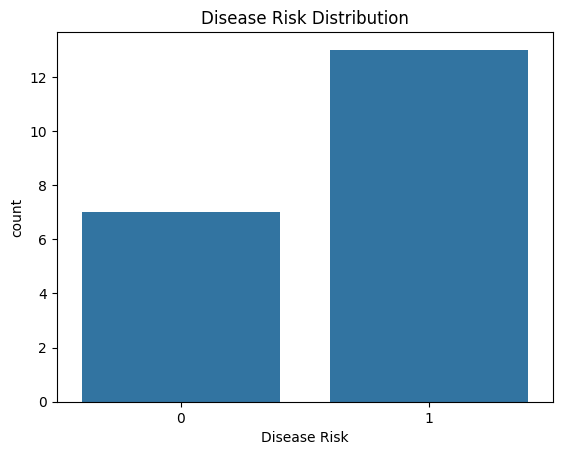

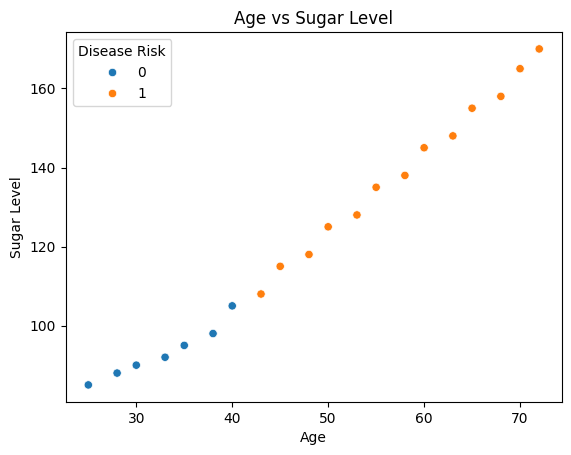

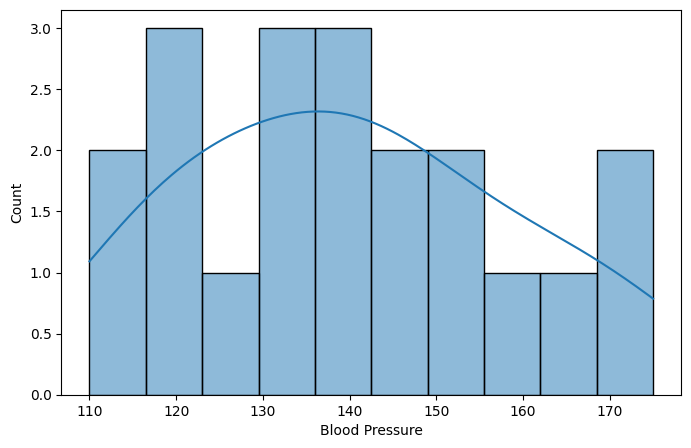

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4

High Disease Risk


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df = pd.read_csv("Health_checkup.csv")

df.columns = df.columns.str.strip()
df.rename(columns={'Blood Presure': 'Blood Pressure'}, inplace=True)

print(df.head())
print(df.info())
print(df.describe())

sns.countplot(x='Disease Risk', data=df)
plt.title("Disease Risk Distribution")
plt.show()

sns.scatterplot(
    x='Age',
    y='Sugar Level',
    hue='Disease Risk',
    data=df
)

plt.title("Age vs Sugar Level")
plt.show()


plt.figure(figsize=(8,5))
sns.histplot(df['Blood Pressure'], bins=10, kde=True)
plt.show()

X = df[['Age', 'Blood Pressure', 'Sugar Level']]
y = df['Disease Risk']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)


log_model = LogisticRegression()

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


print(classification_report(y_test, y_pred))

new_patient = np.array([[50, 145, 130]])

prediction = log_model.predict(new_patient)

if prediction[0] == 1:
    print("High Disease Risk")
else:
    print("Low Disease Risk")